<a href="https://colab.research.google.com/github/Anagha-mathew/bias-variance-visualization/blob/main/Bias_Variance_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bias-Variance Tradeoff

This project demonstrates underfitting, overfitting, and optimal model complexity using polynomial regression.



##1. Import:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


##2.Data Generation:

In [2]:
np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = X**2 + np.random.randn(100, 1) * 2


##3.Train-Test Split:

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


##4.Model Creation:

In [4]:
# 3 Models
models = {
    "Underfitting (Degree 1)": make_pipeline(PolynomialFeatures(1), LinearRegression()),
    "Good Fit (Degree 2)": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "Overfitting (Degree 10)": make_pipeline(PolynomialFeatures(10), LinearRegression())
}



##5.Main Loop:

Underfitting (Degree 1)
Train Error: 16.51
Test Error: 14.70

Good Fit (Degree 2)
Train Error: 3.59
Test Error: 3.08

Overfitting (Degree 10)
Train Error: 3.44
Test Error: 3.42



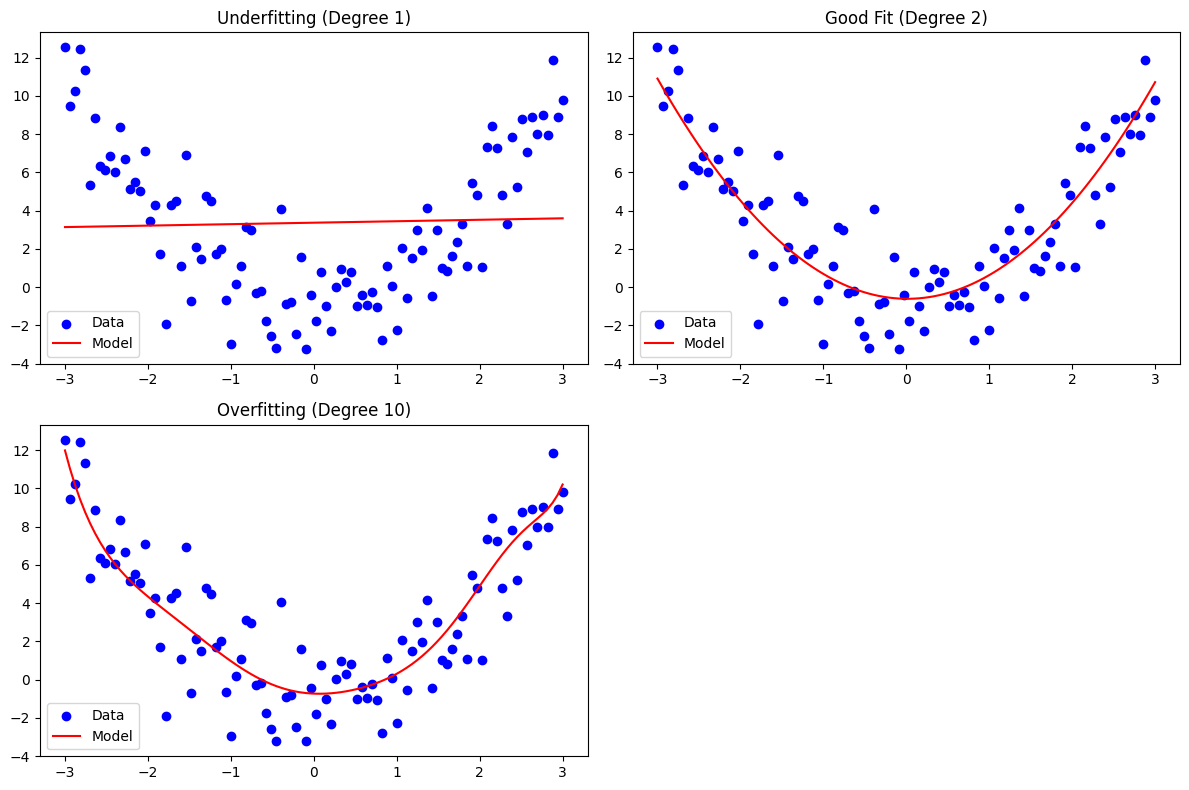

In [5]:
# Plot results
plt.figure(figsize=(12, 8))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)   #train model

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    print(f"{name}")
    print(f"Train Error: {train_error:.2f}")
    print(f"Test Error: {test_error:.2f}\n")

    plt.subplot(2, 2, i+1)
    plt.scatter(X, y, color='blue', label='Data')
    plt.plot(X, model.predict(X), color='red', label='Model')
    plt.title(name)
    plt.legend()

plt.tight_layout()
plt.show()